# Model lab – Ocean Exercise

## Do CMIP6 models simulate the El Niño–Southern Oscillation (ENSO) variability?

In [18]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

# for catalog
import intake
import intake_esm
import gcsfs

%matplotlib inline

### Find the right variables for analysis: SST - sea surface temperature. Choose the model to analyse.

<details>
    <summary>Hint</summary>
You can look it up <a href="https://clipc-services.ceda.ac.uk/dreq/index/var.html">here</a> or in <a href="https://github.com/PCMDI/cmip6-cmor-tables">CMOR-tables</a> or  <a href="https://clipc-services.ceda.ac.uk/dreq/mipVars.html">MPI-variables</a>
</details>

'tos'

### Read the data for the correct period (1850-2014)

In [19]:
# load the catalog
cmip6_catalog_path = '/mnt/tacco-ns1004k/catalogs/merged_local.json'
cmip6_catalog = intake.open_esm_datastore(cmip6_catalog_path)

# filter the catalog for a model, e.g. 'CESM2', the variable tos, and the needed time-period
cat_subset = cmip6_catalog.search(experiment_id = "historical", variable_id = "tos", grid_label = "gr", source_id="CESM2", time_range = "185001-201412", member_id = "r1i1p1f1")
cat_subset.unique()['path']

['/mnt/tacco-ns1004k-cmip/NCAR/CESM2/historical/r1i1p1f1/Omon/tos/gr/v20190308/tos_Omon_CESM2_historical_r1i1p1f1_gr_185001-201412.nc',
 '/mnt/tacco-ns1004k-cmip-betzy/NCAR/CESM2/historical/r1i1p1f1/Omon/tos/gr/v20190308/tos_Omon_CESM2_historical_r1i1p1f1_gr_185001-201412.nc']

The same outpt is stored in 2 different locations, so chose any.

In [20]:
# define path
path_CESM2_tos = cat_subset.df.path[0]
# load data
tos = xr.open_dataset(path_CESM2_tos)

/opt/conda/envs/labs/lib/python3.11/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'tos' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


Inspect for a random time snapshot

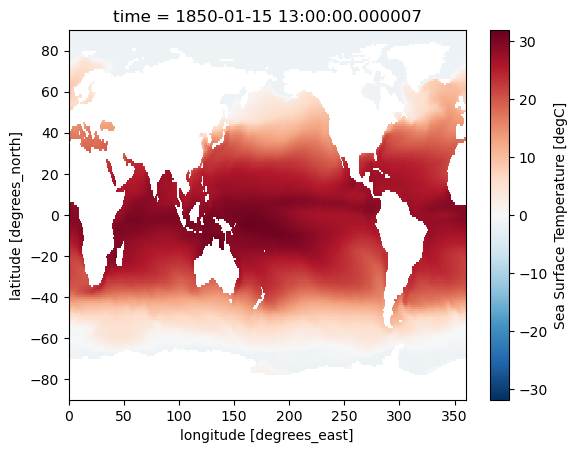

In [21]:
tos.tos.isel(time=0).plot()

### Calculate Nino SST Indices (Nino 1+2, 3, 3.4, 4; ONI and TNI)

<details>
    <summary>Hint</summary>
You can look up  definitions <a href="https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni">here</a> and <a href="https://www.climate.gov/news-features/understanding-climate/climate-variability-oceanic-nino-index">here</a>.
</details>

In [7]:
from IPython.display import Image
Image(url='https://climatedataguide.ucar.edu/sites/default/files/users/dschneid/key_figures_428.png')

**Nino X Index computation**<br>
(a) Compute area averaged total SST from Niño X region<br>
(b) Compute monthly climatology (e.g., 1950-1979) for area averaged total SST from Niño X region, and subtract climatology from area averaged total SST time series to obtain anomalies<br>
(c) Smooth the anomalies with a 5-month running mean<br>
(d) Normalize the smoothed values by its standard deviation over the climatological period.

**Oceanic Nino Index ONI**<br>
= Variations in 3-month running means of SSTs in central Pacific region defined as Nino 3.4; <br>
SST averaged over the Nino 3.4 region (5N-5S, 170W-120W)

**TNI computation**<br>
(a) Compute area averaged total SST from Niño 1+2 region <br>
(b) Compute area averaged total SST from Niño 4 region <br>
(c) Compute monthly climatologies (e.g., 1950-1979) for area averaged total SST from Niño 1+2 region, and Niño 4 region, and subtract climatologies from area averaged total SST time series to obtain anomalies<br>
(d) Normalize each time series of anomalies by their respective standard deviations over the climatological period<br>
(e) Define the raw TNI as Niño 1+2 normalized anomalies minus Niño 4 normalized anomalies<br>
(f) Smooth the raw TNI with a 5-month running mean <br>
(g) Normalize the smoothed TNI by its standard deviation over the climatological period.

# Nino 3.4
(exemplary for Nino X calculation)<br>

Chose a climatological baseline period. When analyzing past climate during such a large period (1850-2014), one could use the entire period as the climatological baseline period. When evaluating the climate or anomalies in the more recent past or present, the WMO most recent climatological baseline period is commonly used (see notebook Intro_Climate_Analysis). Different climatological baseline periods have different advantages. Think about what you want to compare against, and check what is commonly used in literature. Here we now choose the entrie period as the climatological baseline period.

Region of interest: (5N-5S, 170W-120W)

Select spatial region using `.sel()` or `.where()`. It doesn't matter which you choose: <br>

In [22]:
# way 1 
tos_nino34 = tos['tos'].sel(lat=slice(-5, 5), lon=slice(190, 240))

# way 2
tos_nino34 = tos['tos'].where((tos.lat < 5) & (tos.lat > -5) & (tos.lon > 190) & (tos.lon < 240), drop=True)

Average over the area (i.e., area-weighted average over the the values for each cell)

In [23]:
weights = np.cos(np.deg2rad(tos.lat)) # weights for each gridcell (constant in time!)
tos_nino34 = tos_nino34.weighted(weights) # calculate weighted tas mean
tos_nino34 = tos_nino34.mean(("lon", "lat")) # calculate spatial mean

In [24]:
# or do everything in one line thanks to python :-) this does the same as the many lines above
tos_nino34 = tos['tos'].sel(time=slice('1850','2014')).sel(lat=slice(-5, 5), lon=slice(190, 240)).weighted(weights).mean(("lon", "lat"))

In [29]:
#check
tos_nino34

<xarray.DataArray 'tos' (time: 1980)> Size: 16kB
array([27.78758673, 28.23164639, 28.74385882, ..., 25.40214538,
       25.68021991, 26.01812147])
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...

-->contains SST area averaged over the area that we sliced out for each month (has a timestamp)<br>
time is in cft time

In [30]:
# calculate the climatological mean SST for each month of the year during our baseline period
monthly_clim = tos_nino34.groupby('time.month').mean()
monthly_clim #check

<xarray.DataArray 'tos' (month: 12)> Size: 96B
array([26.80195718, 27.07374679, 27.47234558, 27.92679126, 28.16645687,
       28.01129577, 27.52556127, 26.79160045, 26.25821495, 26.172583  ,
       26.42800183, 26.66025002])
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [31]:
# subtract monthly climatology from values
anomalies = tos_nino34 - monthly_clim.sel(month=tos_nino34['time.month'])
anomalies # check

<xarray.DataArray 'tos' (time: 1980)> Size: 16kB
array([ 0.98562954,  1.1578996 ,  1.27151324, ..., -0.77043761,
       -0.74778191, -0.64212855])
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...
    month    (time) int64 16kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [32]:
# smooth anomalies with 5-month running mean (i.e. filter processes with lower lower period then 5months out)
anomalies_smoothed = anomalies.rolling(time=5, center=True).mean()
anomalies_smoothed #check

<xarray.DataArray 'tos' (time: 1980)> Size: 16kB
array([        nan,         nan,  1.18360052, ..., -0.74159449,
               nan,         nan])
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...
    month    (time) int64 16kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

In [33]:
# Subtract the climatological mean and divide by the climatological standard deviation
anomalies_smoothed_std = anomalies_smoothed.groupby('time.month').std()
anomalies_smoothed_normalized = (anomalies_smoothed - anomalies_smoothed_std.sel(month=anomalies_smoothed['time.month'])) / anomalies_smoothed_std.sel(month=anomalies_smoothed['time.month'])

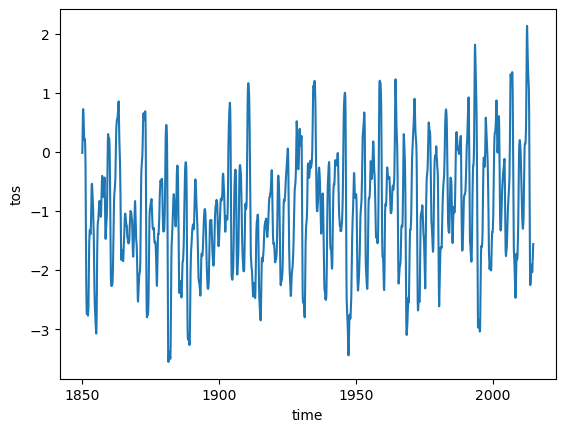

In [35]:
# and that's how NINO3.4 is defined! let's plot it
NINO34 = anomalies_smoothed_normalized
NINO34.plot()

The same procedure is applied for the other NINO X indices, just with different regions in the ocean. Comparing the indices gives insight into

# ONI

Uses the same region as Nino 3.4, thus we can reuse the variables and change from the running mean on:

In [36]:
# smooth anomalies with 5-month running mean (i.e. filter processes with lower lower period then 5months out)
anomalies_smoothed_ONI = anomalies.rolling(time=3, center=True).mean()
anomalies_smoothed_ONI #check

<xarray.DataArray 'tos' (time: 1980)> Size: 16kB
array([        nan,  1.13834746,  1.22191767, ..., -0.76421924,
       -0.72011603,         nan])
Coordinates:
  * time     (time) object 16kB 1850-01-15 13:00:00.000007 ... 2014-12-15 12:...
    month    (time) int64 16kB 1 2 3 4 5 6 7 8 9 10 ... 3 4 5 6 7 8 9 10 11 12

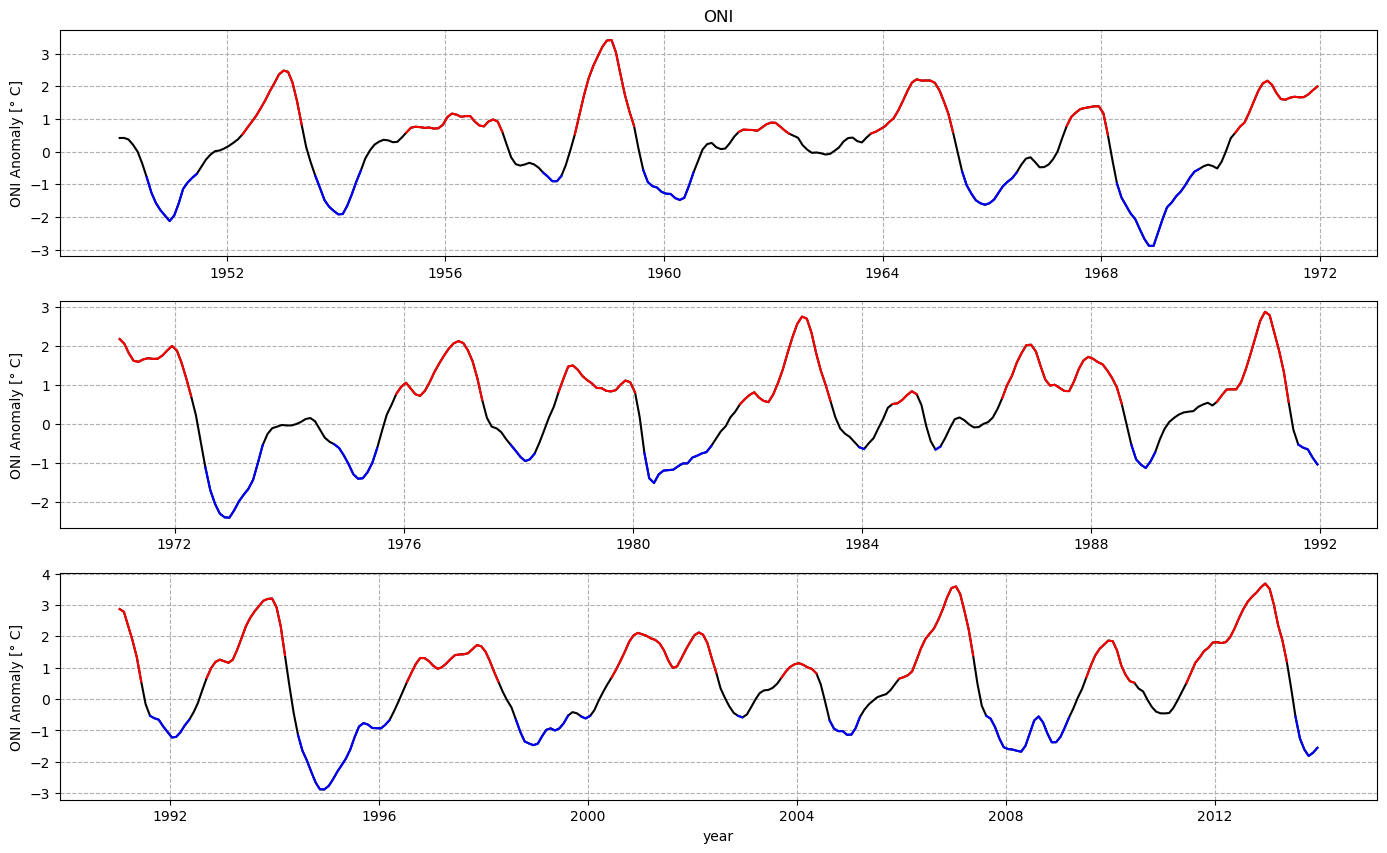

In [37]:
# example plot recreating the observations / plot from slide

fig, ax = plt.subplots(3, 1, figsize = (17, 10))

time = anomalies_smoothed_ONI.time.astype("datetime64[ns]")

ax[0].plot(time.sel(time=slice('1950','1971')), anomalies_smoothed_ONI.sel(time=slice('1950','1971')), color='black', label='anomaly')
ax[0].plot(time.sel(time=slice('1950','1971')).where(anomalies_smoothed_ONI>0.5),anomalies_smoothed_ONI.sel(time=slice('1950','1971')).where(anomalies_smoothed_ONI>=0.5), label='El Niño', color='red')
ax[0].plot(time.sel(time=slice('1950','1971')).where(anomalies_smoothed_ONI<=-0.5),anomalies_smoothed_ONI.sel(time=slice('1950','1971')).where(anomalies_smoothed_ONI<=-0.5), label='La Niña', color='blue')

ax[0].set_title('ONI')    
ax[2].set_xlabel('year')
for i in range(0,3):
    ax[i].set_ylabel('ONI Anomaly [° C]')
    ax[i].grid(linestyle='--')


ax[1].plot(time.sel(time=slice('1971','1991')), anomalies_smoothed_ONI.sel(time=slice('1971','1991')), color='black', label='anomaly')
ax[1].plot(time.sel(time=slice('1971','1991')).where(anomalies_smoothed_ONI>0.5),anomalies_smoothed_ONI.sel(time=slice('1971','1991')).where(anomalies_smoothed_ONI>=0.5), label='El Niño', color='red')
ax[1].plot(time.sel(time=slice('1971','1991')).where(anomalies_smoothed_ONI<=-0.5),anomalies_smoothed_ONI.sel(time=slice('1971','1991')).where(anomalies_smoothed_ONI<=-0.5), label='La Niña', color='blue')

ax[2].plot(time.sel(time=slice('1991','2013')), anomalies_smoothed_ONI.sel(time=slice('1991','2013')), color='black', label='anomaly')
ax[2].plot(time.sel(time=slice('1991','2013')).where(anomalies_smoothed_ONI>0.5),anomalies_smoothed_ONI.sel(time=slice('1991','2013')).where(anomalies_smoothed_ONI>=0.5), label='El Niño', color='red')
ax[2].plot(time.sel(time=slice('1991','2013')).where(anomalies_smoothed_ONI<=-0.5),anomalies_smoothed_ONI.sel(time=slice('1991','2013')).where(anomalies_smoothed_ONI<=-0.5), label='La Niña', color='blue')


--> whenever 5 consecutive month are red/blue, it's classified as a El Nino / La Nina event acc. to the ONI index

# TNI

calculate like in the recipe above

"To define the unique character of each El Niño or La Niña event, Trenberth and Stepaniak (2001) argue that the Niño 3.4 index should be used in combination with an index that  they introduce, called the Trans-Niño Index (TNI).  The TNI is defined to be the **difference in normalized SST anomalies between the Niño 1+2 and Niño 4 regions**.  The TNI thus **measures the gradient in SST anomalies between the central and eastern equatorial Pacific**.  When the SST gradient is particularly large (say, due to positive anomalies in the Niño 4 region and negative anomalies in the Niño 1+2 region), some researchers classify the event as a "central Pacific El Niño " or "El  Niño Modoki," although the distinction of this type of event as a seperate phenonomenon is a matter or debate." (NCAR, https://climatedataguide.ucar.edu/climate-data/nino-sst-indices-nino-12-3-34-4-oni-and-tni)